# 语言模型
语言模型（Language Model，LM）是人工智能领域中用于理解和生成人类语言的核心工具，其本质是通过数学方法对自然语言的概率分布进行建模。  
- 计算词序列概率的模型
- 评估句子的流畅度和合理性
- 形式化描述：P(w₁,w₂,…,wₙ)

## 统计原理
**N-gram模型**  
计算连续N个词（如2-gram、3-gram）的共现频率来预测下一个词  

**马尔可夫假设**  
- 当前词只依赖前n-1个词，简化计算但忽略长距离依赖
- 简化概率计算：P(wᵢ|w₁,…,wᵢ₋₁) ≈ P(wᵢ|wᵢ₋ₙ₊₁,…,wᵢ₋₁)

局限性
- 数据稀疏问题
- 长距离依赖难以捕捉
- 上下文信息有限

## 神经网络模型
**前馈神经网络模型**    
基本结构  
- 输入层：前n-1个词的one-hot表示
- 嵌入层：学习词向量
- 隐藏层：非线性变换
- 输出层：预测下一个词的概率分布

优势
- 分布式表示缓解数据稀疏
- 自动学习特征组合
- 更好的泛化能力

**循环神经网络模型**  
RNN结构
- 循环处理变长序列
- 隐藏状态传递历史信息
- 存在梯度消失问题

LSTM/GRU
- 解决梯度消失问题
- 改进RNN，通过门控机制解决长距离依赖问题
- 更稳定的训练过程

**Transformer架构**     
现代语言模型的主流，通过自注意力机制（Self-Attention）并行处理整个序列，显著提升效率。
- 全局上下文建模
- 并行计算优势
- 位置编码处理词序

**预训练语言模型**
- BERT：双向上下文表示
- GPT：自回归生成模型
- 强大的迁移学习能力

## 概率语法模型
概率上下文无关文法  
基本概念
- 为CFG规则赋予概率
- P(X → γ)表示规则应用概率
- 句子的概率是推导路径概率的乘积

参数估计
- 从树库中计数规则应用
- 最大似然估计
- 平滑处理稀疏规则

## 依存语法模型
概率依存文法
- 为依存关系赋予概率
- 基于词汇共现统计
- 考虑距离和语法约束

解析算法
- 基于图的算法（Eisner算法）
- 基于转移的算法
- 神经网络解析器

# 文本预处理
文本清洗、分词和词性标注  
## 文本清洗
- 编码格式处理  
不同来源的文本可能采用不同的编码格式（如UTF-8、GBK、ASCII等），统一编码是首要任务：
  - 使用chardet库自动检测编码

  - 统一转换为UTF-8编码

  - 处理无法解码的字符（通常替换或忽略）

- 特殊字符处理  
不同场景下需要处理不同类型的特殊字符：  

|字符类型	|处理方法	|应用场景|
|---|---|---|
|HTML标签	|正则表达式移除	|网页爬取文本|
|表情符号	|移除或转换为文字描述	|社交媒体分析|
|控制字符	|过滤掉	|所有文本处理|
|特殊标点	|标准化处理	|文本规范化|  

- 噪声数据去除
  - 去除无关信息（广告、版权声明等）
  - 处理拼写错误（使用拼写检查库）

  - 标准化数字表示（如将"1000"统一为"1,000"）
  
  - 统一日期格式（"2023-01-01" vs "01/01/2023"）

In [ ]:
# 编码转换示例
text = "示例文本".encode('gbk')  # 假设原始编码是GBK
text = text.decode('gbk').encode('utf-8')  # 转换为UTF-8

In [ ]:
import re

# 移除HTML标签示例
text = "<p>这是一段<b>HTML</b>文本</p>"
clean_text = re.sub(r'<[^>]+>', '', text)
print(clean_text)  # 输出: 这是一段HTML文本

## 分词
分词（Tokenization）是将连续文本分割成有意义的语言单元（token）的过程，不同语言需要不同的分词方法
- 英文分词方法  
英文分词相对简单，主要基于空格和标点分割：
  - 处理缩写（如"I'm"→"I"+"'m"）

  - 保留或合并特定短语（如"New York"作为一个token）

  - 处理连字符（"state-of-the-art"）

- 中文分词技术   
中文没有明显的词边界，分词更为复杂。主要方法包括：
  - 基于词典的分词：最大匹配法、最短路径法

  - 基于统计的分词：HMM、CRF等序列标注方法

  - 基于深度学习的分词：BiLSTM-CRF、BERT等模型  

```py
# 使用NLTK进行英文分词
from nltk.tokenize import word_tokenize

text = "Natural Language Processing is fascinating!"
tokens = word_tokenize(text)
print(tokens)  # ['Natural', 'Language', 'Processing', 'is', 'fascinating', '!']

```py
# 使用jieba进行中文分词
import jieba

text = "自然语言处理非常有趣"
tokens = jieba.lcut(text)
print(tokens)  # ['自然语言', '处理', '非常', '有趣']

子词分词（Subword Tokenization）  
解决罕见词和词表膨胀问题，常用方法：
- **Byte Pair Encoding (BPE)**：通过合并高频字符对构建子词

- WordPiece：类似BPE，但基于概率合并

- Unigram Language Model：从大词表开始逐步删除低概率子词

```py
# 使用HuggingFace的tokenizer示例
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-chinese')
tokens = tokenizer.tokenize("自然语言处理")
print(tokens)  # ['自', '然', '语', '言', '处', '理']

常用分词工具对比

|工具名称	|支持语言	|特点	|适用场景|
|---|---|---|---|
|NLTK	|英文为主	|功能全面，速度一般	|教学、研究|
|spaCy	|多语言	|工业级，速度快	|生产环境|
|jieba	|中文	|简单易用，词典可扩展	|中文处理|
|Stanford CoreNLP	|多语言	|准确度高，资源消耗大	|学术研究|
|HuggingFace Tokenizers	|多语言	|支持子词分词	|深度学习|

## 词性标注
词性标注（Part-of-Speech Tagging）是为分词结果中的每个词语标注其词性类别的过程  
词性标注有助于：理解句子结构，消除词义歧义，支持更高级的NLP任务（如句法分析）  
  
常见词性体系  
不同语言和工具使用不同的词性标注体系：  

英文常用Penn Treebank标签集（部分）：
- NN：名词
- VB：动词
- JJ：形容词
- RB：副词
- PRP：代词

中文常用ICTCLAS标签集（部分）：
- n：名词
- v：动词
- a：形容词
- d：副词
- r：代词

自动词性标注方法
- 基于规则的方法：使用手工编写的规则进行标注
- 基于统计的方法：HMM、MaxEnt等模型
- 基于深度学习的方法：RNN、Transformer等神经网络

```py
# 使用spaCy进行词性标注
import spacy

nlp = spacy.load("en_core_web_sm")
doc = nlp("Natural Language Processing is fascinating!")
for token in doc:
    print(token.text, token.pos_)  # 输出每个词及其词性标签

词性标注的评估指标：
- 准确率（Accuracy）

- 未知词准确率（OOV Accuracy）

- 混淆矩阵分析

# 文本表示方法
将非结构化的文本数据转化为计算机可以处理的数值形式。  
## 传统文本表示
### 词袋模型（Bag of Words）  
词袋模型是最简单的文本表示方法之一，它将文本视为一个无序的词汇集合。  
- 忽略词语顺序和语法，只关注词语是否出现
- 构建词汇表，统计每个词在文档中出现的次数
- 最终表示为一个高维稀疏向量

✅ 优点：
- 实现简单，计算效率高
- 适用于小规模数据集和简单任务

❌ 缺点：
- 忽略词序和语义信息
- 高维稀疏性问题
- 无法处理同义词和多义词

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

corpus = [
    'This is the first document.',
    'This document is the second document.',
    'And this is the third one.',
    'Is this the first document?'
]

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(corpus)
print(vectorizer.get_feature_names_out())
print(X.toarray())

### TF-IDF  
TF-IDF（Term Frequency-Inverse Document Frequency）是对词袋模型的改进，考虑了词语在整个语料库中的重要性。  
  
计算公式  
- TF（词频）：词在文档中出现的次数 / 文档总词数
- IDF（逆文档频率）：log(文档总数 / 包含该词的文档数)
- TF-IDF = TF × IDF

✅ 优点：
- 降低常见词的影响，突出重要词
- 比简单词袋模型效果更好

❌ 缺点：
- 仍然无法捕捉语义关系
- 高维问题依然存在

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(corpus)
print(tfidf_vectorizer.get_feature_names_out())
print(X_tfidf.toarray())

### N-gram 模型  
N-gram 模型考虑了词语的顺序信息，通过连续n个词的组合来表示文本。  

常见类型
- Unigram (1-gram)：单个词
- Bigram (2-gram)：两个连续词的组合
- Trigram (3-gram)：三个连续词的组合

✅ 优点：
- 捕捉局部词序信息
- 可以表示短语和固定搭配

❌ 缺点：
- 维度爆炸问题更严重
- 仍然无法处理长距离依赖

In [ ]:
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2))
X_bigram = bigram_vectorizer.fit_transform(corpus)
print(bigram_vectorizer.get_feature_names_out())

## 词向量表示
### Word2Vec 
Word2Vec 是一种基于神经网络的词向量表示方法，由 Google 在 2013 年提出。  
  
两种模型架构
- CBOW（Continuous Bag of Words）：通过上下文预测当前词
- Skip-gram：通过当前词预测上下文

特点
- 低维稠密向量（通常50-300维）
- 可以捕捉词语的语义和语法关系
- 支持向量运算（如：king - man + woman ≈ queen）

```py
from gensim.models import Word2Vec

sentences = [["cat", "say", "meow"], ["dog", "say", "woof"]]
model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4)

# 获取词向量
vector = model.wv['cat']
# 找相似词
similar_words = model.wv.most_similar('cat')

### GloVe 词向量
GloVe（Global Vectors for Word Representation）结合了全局统计信息和局部上下文窗口的优点。

核心思想
- 基于词共现矩阵
- 优化目标是使两个词的向量点积等于它们共现次数的对数
  
|特性	|Word2Vec	|GloVe|
|---|---|---|
|训练方式	|局部窗口	|全局统计|
|计算效率	|较高	|较低|
|小数据集表现	|较好	|一般|
|大数据集表现	|好	|更好|

### FastText
FastText 是 Facebook 开发的词向量模型，特点是考虑子词（subword）信息。   
  
主要特点
- 将词表示为字符n-gram的集合
- 可以处理未登录词（OOV）
- 特别适合形态丰富的语言

```py
from gensim.models import FastText

model = FastText(sentences, vector_size=100, window=5, min_count=1, workers=4)
# 即使单词不在词典中也能获得向量
vector = model.wv['unseenword']

## 上下文感知的表示
### ELMo 模型
ELMo（Embeddings from Language Models）是最早的上下文相关词表示方法之一。  
  
核心特点
- 基于双向LSTM语言模型
- 词语的表示取决于整个输入句子
- 生成多层表示（可以组合不同层次的语义）


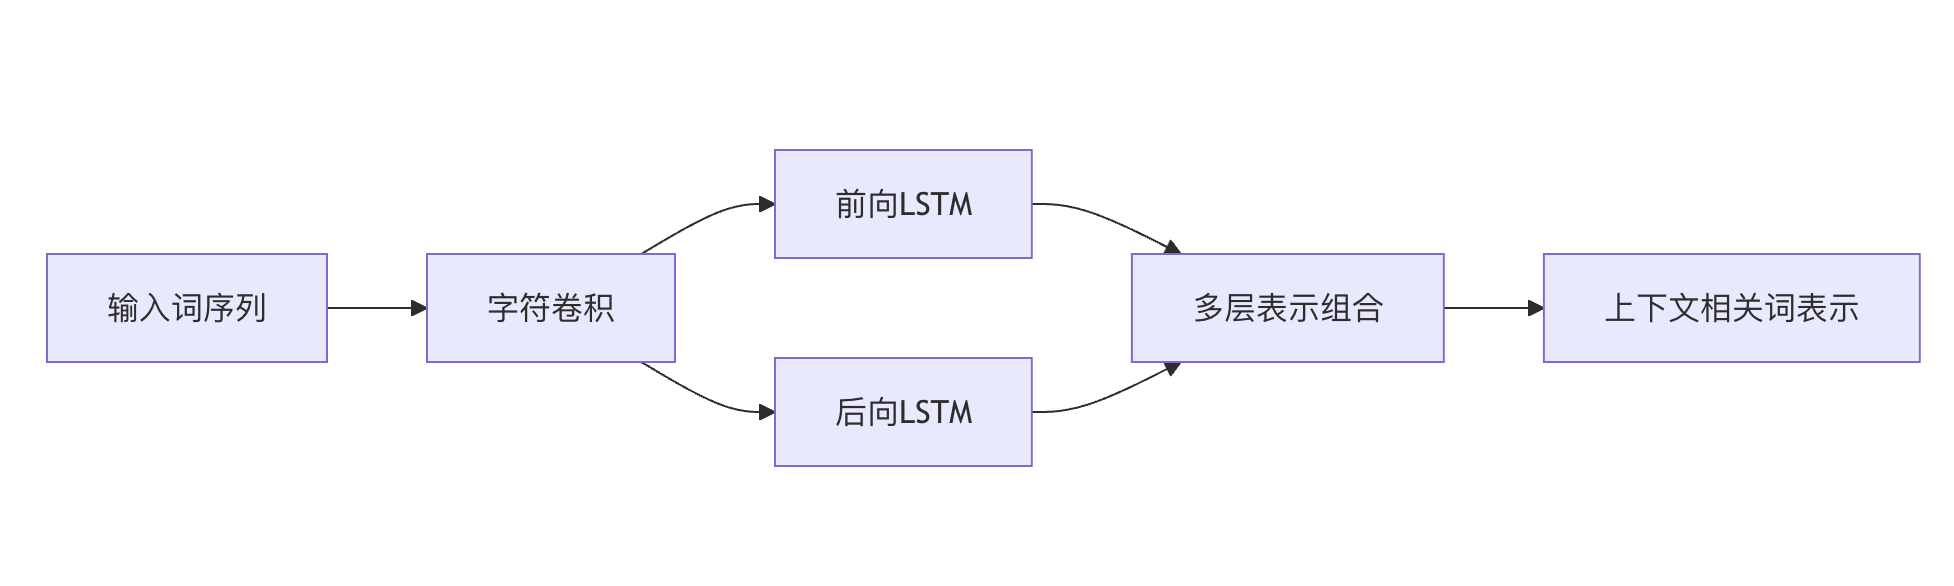

### BERT 及其变体
BERT（Bidirectional Encoder Representations from Transformers）是 Google 提出的预训练语言模型。  
  
关键创新
- Transformer 架构
- 掩码语言模型（MLM）训练目标
- 下一句预测（NSP）任务

常见变体
- RoBERTa：优化训练策略
- DistilBERT：轻量版BERT
- ALBERT：参数共享减少模型大小

```py
from transformers import BertTokenizer, BertModel

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

inputs = tokenizer("Hello, my dog is cute", return_tensors="pt")
outputs = model(**inputs)
last_hidden_states = outputs.last_hidden_state

现代NLP主要使用预训练+微调范式：
- 预训练阶段：在大规模语料上训练通用语言表示
- 微调阶段：在特定任务数据上调整模型参数
  
|模型	|发布时间|	主要特点|
|---|---|---|
|Word2Vec	|2013|	静态词向量|
|GloVe	|2014|	全局统计+局部窗口|
|ELMo	|2018|	双向LSTM，上下文相关|
|BERT	|2018|	Transformer，双向上下文|
|GPT-3	|2020|	单向Transformer，生成能力强|

## 文档级表示
### Doc2Vec
Doc2Vec 是 Word2Vec 的扩展，可以直接学习文档的向量表示。  
  
两种模型
- PV-DM（Distributed Memory）：类似CBOW，加入文档ID
- PV-DBOW（Distributed Bag of Words）：类似Skip-gram

```py
from gensim.models import Doc2Vec
from gensim.models.doc2vec import TaggedDocument

documents = [TaggedDocument(doc, [i]) for i, doc in enumerate(corpus)]
model = Doc2Vec(documents, vector_size=100, window=5, min_count=1, workers=4)
vector = model.infer_vector(["new", "document", "text"])

### 句向量与文档向量
常用方法
- 平均法：对词向量取平均
- SIF：平滑逆频率加权平均
- BERT句向量：使用[CLS]标记或平均所有词向量

```py
# 使用Sentence-BERT
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
sentences = ["This is an example sentence", "Each sentence is converted"]
embeddings = model.encode(sentences)

### 主题模型（LDA）
潜在狄利克雷分配（LDA）是一种无监督的主题建模方法。  
  
基本原理
- 将文档表示为多个主题的混合
- 每个主题是词语的概率分布
- 通过变分推断或Gibbs采样学习

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(corpus)
lda = LatentDirichletAllocation(n_components=2)
lda.fit(X)

文本表示方法的发展经历了从简单统计到深度学习的演进：
- 传统方法：简单高效，适合小规模数据

- 词向量：捕捉语义关系，维度低

- 上下文感知模型：动态表示，效果最好但计算成本高

- 文档表示：从词级别扩展到文档级别

选择文本表示方法时应考虑：
- 任务需求（是否需要语义理解）

- 数据规模

- 计算资源

- 语言特性

随着大语言模型的发展，文本表示技术仍在快速演进，但理解这些基础方法对于掌握NLP仍然至关重要。

# 文本分类
将给定的文本文档自动归类到一个或多个预定义的类别中。
  
- 情感分析：判断评论是正面还是负面
- 垃圾邮件过滤：区分正常邮件和垃圾邮件
- 新闻分类：将新闻归类到体育、财经、科技等板块
- 意图识别：理解用户查询的真实意图
- 医疗诊断：根据症状描述分类疾病类型

## 流程与方法
原始文本--文本预处理--特征提取--分类模型--分类结果  

1. 文本预处理
文本预处理是将原始文本转换为适合机器学习模型处理的形式

```py
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

## 1. 文本预处理
def preprocess_text(text):
    # 转换为小写
    text = text.lower()
    # 移除特殊字符和数字
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # 分词
    words = text.split()
    # 移除停用词
    stop_words = set(stopwords.words('english'))
    words = [word for word in words if word not in stop_words]
    # 词干提取
    stemmer = PorterStemmer()
    words = [stemmer.stem(word) for word in words]
    return ' '.join(words)

2. 特征提取
将文本转换为数值特征表示，常见方法包括：

|方法	|描述	|优点	|缺点|
|---|---|---|---|
|词袋模型(BoW)	|统计词频	|简单直观|	忽略词序和语义|
|TF-IDF	|考虑词的重要性	|比BoW更精确|	仍然忽略上下文|
|Word2Vec	|词向量表示	|捕捉语义关系|	无法处理多义词|
|BERT	|上下文嵌入	|最先进的表示	|计算资源要求高|

3. 分类模型选择

传统机器学习方法：  
- 朴素贝叶斯
- 支持向量机(SVM)
- 逻辑回归
- 随机森林

深度学习方法：
- 卷积神经网络(CNN)
- 循环神经网络(RNN/LSTM)
- Transformer模型(BERT等)

## 示例

In [ ]:
## 实践示例：新闻分类

from sklearn.datasets import fetch_20newsgroups

# 选择4个类别作为示例
categories = ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']

# 加载训练集和测试集
newsgroups_train = fetch_20newsgroups(subset='train', categories=categories)
newsgroups_test = fetch_20newsgroups(subset='test', categories=categories)

print(f"训练集样本数: {len(newsgroups_train.data)}")
print(f"测试集样本数: {len(newsgroups_test.data)}")

from sklearn.feature_extraction.text import TfidfVectorizer

# 创建TF-IDF向量化器
vectorizer = TfidfVectorizer(max_features=5000)

# 转换训练集和测试集
X_train = vectorizer.fit_transform(newsgroups_train.data)
X_test = vectorizer.transform(newsgroups_test.data)

y_train = newsgroups_train.target
y_test = newsgroups_test.target

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 创建并训练模型
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 预测测试集
y_pred = model.predict(X_test)

# 评估模型
print(f"准确率: {accuracy_score(y_test, y_pred):.2f}")
print("\n分类报告:")
print(classification_report(y_test, y_pred, target_names=newsgroups_test.target_names))

处理类别不平衡
- 重采样(过采样少数类或欠采样多数类)
- 使用类别权重
- 尝试不同的评估指标(如F1-score而不是准确率)

提高模型性能的方法
- 特征工程：
  - 尝试不同的n-gram范围
  - 加入词性特征
  - 使用更高级的词嵌入

- 模型优化：
  - 超参数调优
  - 模型集成
  - 尝试深度学习模型

- 数据增强：
  - 回译(Back Translation)
  - 同义词替换
  - 生成对抗网络(GAN)

常见挑战
1. 多标签分类：一个文档可能属于多个类别
2. 领域适应：模型在新领域的表现下降
3. 小样本学习：标注数据有限的情况
4. 解释性：理解模型为何做出特定分类决策

# 情感分析
通过计算技术自动识别、提取和分析文本中的主观信息，判断作者对特定主题、产品或服务的态度是正面、负面还是中性  

## 基于词典的情感分析方法
## 基于机器学习的情感分析方法
典型特征工程
- 词袋模型(BOW)：文本表示为词语出现频率的向量

- TF-IDF：考虑词语在文档中的重要性

- N-gram特征：捕获局部词语序列模式

- 情感词典特征：结合词典方法的优势

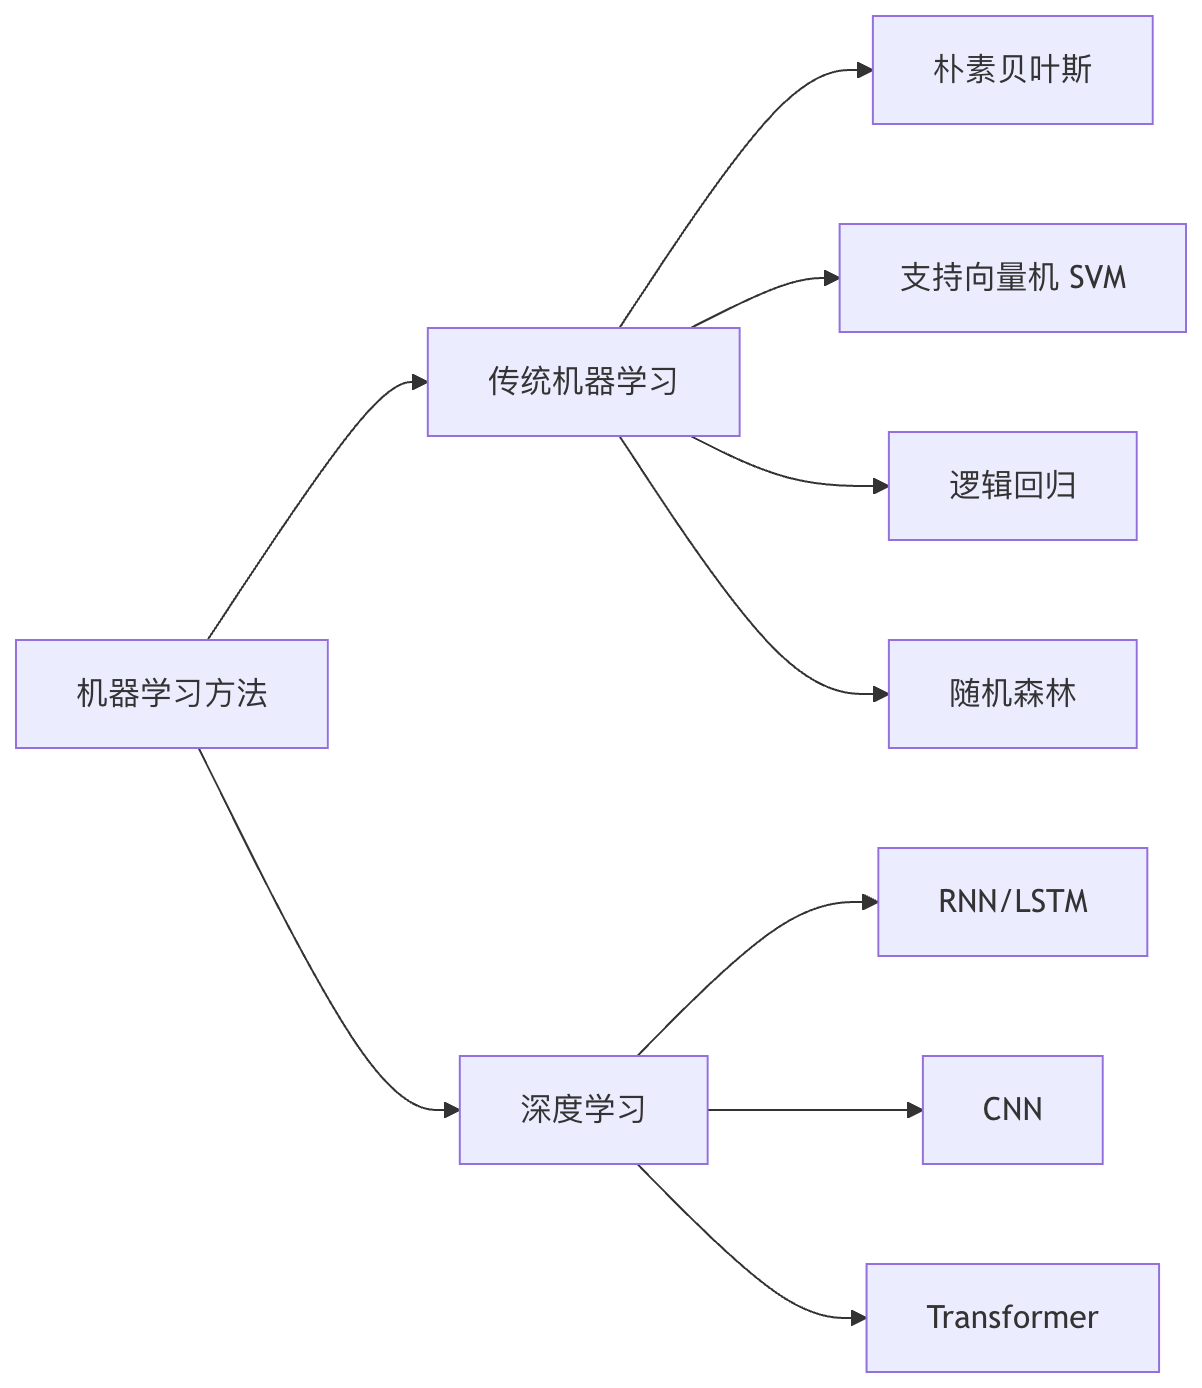

```python
# 使用Scikit-learn实现情感分类
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

# 构建分类管道
sentiment_clf = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2))),
    ('clf', LinearSVC())
])

# 训练模型
sentiment_clf.fit(train_texts, train_labels)

# 预测新文本
prediction = sentiment_clf.predict(["这个产品非常好用，强烈推荐！"])
print(prediction)  # 输出: 'positive'

## 细粒度情感分析
细粒度情感分析(Aspect-Based Sentiment Analysis, ABSA)是更高级的情感分析任务，旨在识别文本中提到的特定方面及其对应的情感。  

ABSA的核心子任务  
- 方面提取：识别文本中讨论的实体或属性
  - 显式方面："手机的电池续航很好" → "电池"
  - 隐式方面："拍出来的照片很清晰" → "摄像头"
- 情感分类：对每个识别出的方面进行情感判断

实现方法对比
|方法类型	|代表模型	|适用场景	|优点	|缺点|
|---|---|---|---|---|
|流水线方法	|先CRF提取方面，再分类器判断情感	|资源有限场景	|模块清晰，易于调试	|误差传播|
|端到端方法	|BERT-ABSA、AOA-LSTM	|高精度要求	|联合优化，性能更好	|需要更多数据|
|多任务学习	|MT-DNN、Multi-Task BERT	|相关任务辅助	|知识共享	|任务平衡困难|

```py
# 基于BERT的方面级情感分析
from transformers import BertTokenizer, BertForSequenceClassification
import torch

# 加载预训练模型
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=3)
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# 准备输入
text = "餐厅的环境很棒，但服务太慢了。"
aspect = "服务"
inputs = tokenizer(f"[CLS] {aspect} [SEP] {text} [SEP]", return_tensors="pt")

# 预测情感
outputs = model(**inputs)
predictions = torch.argmax(outputs.logits, dim=1)
print(predictions)  # 可能输出: 1 (负面)

# 命名实体识别
命名实体识别（Named Entity Recognition，简称 NER）是自然语言处理（NLP）中的一项基础任务，它的目标是识别文本中具有特定意义的实体，并将其分类到预定义的类别中  
- 命名实体：文本中表示特定对象的专有名词
- 实体类别：常见类型包括人名、地名、组织机构名、时间、日期、货币等

基本方法
|方法类型	|描述|	优缺点|
|---|---|---|
|规则匹配	|基于预定义规则和词典|	高精度但覆盖率低|
|统计学习	|使用传统机器学习模型|	需要特征工程|
|深度学习	|基于神经网络模型|	高性能但需要大量数据|

常用算法
- 条件随机场（CRF）
- 双向LSTM
- BERT等预训练模型

```python
# 使用spaCy进行NER的简单示例
import spacy

# 加载英文模型
nlp = spacy.load("en_core_web_sm")

# 处理文本
text = "Apple is looking at buying U.K. startup for $1 billion"
doc = nlp(text)

# 输出识别结果
for ent in doc.ents:
    print(ent.text, ent.label_)

In [ ]:
# 基于规则的简单NER实现
import re

def rule_based_ner(text):
    # 匹配日期
    dates = re.findall(r'\d{1,2}[/-]\d{1,2}[/-]\d{2,4}', text)
    # 匹配货币
    currencies = re.findall(r'\$\d+\.?\d*', text)
    return {"日期": dates, "货币": currencies}

sample = "会议定于12/15/2023举行,预算为$5000"
print(rule_based_ner(sample))

## 评估指标
关键性能指标
- 精确率（Precision）：识别正确的实体占所有识别实体的比例
- 召回率（Recall）：识别正确的实体占所有实际实体的比例
- F1分数：精确率和召回率的调和平均数

评估示例
假设测试集中有100个实体：  

系统识别出90个，其中80个正确  
精确率 = 80/90 ≈ 89%  
召回率 = 80/100 = 80%  
F1 = 2*(0.89*0.8)/(0.89+0.8) ≈ 84%  

# 关系抽取
关系抽取(Relation Extraction)是自然语言处理中的一个重要任务，旨在从非结构化文本中识别实体之间的语义关系。简单来说，就是从句子中找出"谁"和"谁"之间有什么"关系"  

核心要素
- 实体识别：首先需要识别文本中的命名实体
- 关系分类：然后判断这些实体之间存在什么类型的关系
- 关系表示：最后以结构化形式表示这些关系

## 主要方法
1. 基于规则的方法  
优点：实现简单，准确率高  
缺点：覆盖面有限，难以处理复杂句式

In [ ]:
# 示例：简单的规则匹配
import re

text = "马云创立了阿里巴巴"
pattern = r"(.+?)创立了(.+?)"
match = re.search(pattern, text)
if match:
    print(f"创始人: {match.group(1)}, 公司: {match.group(2)}")

2. 监督学习方法   
使用标注数据进行模型训练，常见算法包括：支持向量机(SVM)，条件随机场(CRF)，深度学习模型

```py
# 示例：使用spaCy进行关系抽取
import spacy

nlp = spacy.load("en_core_web_sm")
text = "Apple was founded by Steve Jobs in 1976."
doc = nlp(text)

for ent in doc.ents:
    print(ent.text, ent.label_)

3. 半监督/远程监督方法  
利用少量标注数据和大量未标注数据  
远程监督：利用知识库自动生成训练数据  

4. 基于预训练语言模型的方法  
BERT，GPT，RoBERTa

```py
# 示例：使用HuggingFace Transformers
from transformers import pipeline

classifier = pipeline("text-classification", model="bert-base-uncased")
result = classifier("马云是阿里巴巴的创始人")
print(result)

## 评估指标
精确率(Precision)  
召回率(Recall)  
F1值  

## 示例

In [ ]:
# 示例数据集
data = [
    {"text": "比尔盖茨是微软的创始人", "relations": [{"head": "比尔盖茨", "tail": "微软", "type": "创始人"}]},
    {"text": "北京是中国的首都", "relations": [{"head": "北京", "tail": "中国", "type": "首都"}]}
]

from sklearn.feature_extraction.text import TfidfVectorizer

texts = [d["text"] for d in data]
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(texts)

from sklearn.svm import SVC

# 简化示例，实际需要更复杂的标签处理
y = [d["relations"][0]["type"] for d in data]  
model = SVC()
model.fit(X, y)

test_text = "乔布斯创立了苹果公司"
test_vec = vectorizer.transform([test_text])
prediction = model.predict(test_vec)
print(f"预测关系: {prediction[0]}")

# 文本相似度计算
旨在量化两个文本片段之间的相似程度。这项技术在信息检索、问答系统、抄袭检测、推荐系统等多个领域都有广泛应用。
- 语义相似度：衡量文本在含义上的接近程度
- 字面相似度：衡量文本在表面词汇上的重叠程度
- 向量空间模型：将文本表示为高维空间中的向量
- 距离度量：计算向量之间的距离或相似度

## 主要方法
1. 基于词频的方法  
词袋模型(Bag of Words)  
TF-IDF    

In [ ]:
# 词袋模型(Bag of Words)  
from sklearn.feature_extraction.text import CountVectorizer

corpus = [
    '我喜欢自然语言处理',
    '我爱学习NLP技术',
    '文本相似度计算很有趣'
]

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(corpus)
print(X.toarray())

In [ ]:
# TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(corpus)
print(tfidf_matrix.toarray())

2. 基于词向量的方法  
Word2Vec 相似度  
句子向量计算  

```py
# Word2Vec 相似度
from gensim.models import Word2Vec

sentences = [
    ['我','喜欢','自然语言处理'],
    ['我','爱','学习','NLP','技术'],
    ['文本','相似度','计算','很','有趣']
]

model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4)
vector = model.wv['自然语言处理']  # 获取词向量

```py
# 句子向量计算
import numpy as np

def sentence_vector(sentence, model):
    vectors = [model.wv[word] for word in sentence if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)

sentence_vec1 = sentence_vector(['我','喜欢','自然语言处理'], model)
sentence_vec2 = sentence_vector(['我','爱','NLP'], model)

3. 基于预训练模型的方法  
BERT 相似度计算  

```py
from transformers import BertTokenizer, BertModel
import torch

tokenizer = BertTokenizer.from_pretrained('bert-base-chinese')
model = BertModel.from_pretrained('bert-base-chinese')

inputs = tokenizer("这是一个示例句子", return_tensors="pt")
outputs = model(**inputs)
last_hidden_states = outputs.last_hidden_state

## 相似度度量指标
|方法名称|特点|
|---|---|
|余弦相似度		|忽略向量长度，专注方向|
|欧氏距离		|考虑向量绝对位置|
|曼哈顿距离		|对异常值不敏感|
|Jaccard相似度 |适用于集合相似度|

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# 计算余弦相似度
similarity = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])
print(f"文本相似度: {similarity[0][0]:.4f}")

## 示例

In [ ]:
# 新闻标题相似度检测
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# 示例数据
titles = [
    "苹果发布新款iPhone手机",
    "苹果公司推出最新智能手机",
    "微软公布季度财报",
    "谷歌宣布新的人工智能计划"
]

# 计算相似度矩阵
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(titles)
similarities = cosine_similarity(tfidf_matrix)

# 显示结果
df = pd.DataFrame(similarities, columns=titles, index=titles)
print(df)

长文本相似度计算：分句处理--计算句间相似度--聚合相似度得分--最终相似度    
  
最佳实践建议  
数据预处理很重要（统一大小写，去除停用词，词干提取/词形还原）  
根据场景选择方法（短文本：BERT等预训练模型，长文档：TF-IDF + 余弦相似度，实时系统：Word2Vec等轻量模型）  
考虑计算效率（大规模数据使用近似最近邻(ANN)算法，考虑使用Faiss等高效相似度搜索库）  
持续评估优化（建立人工评估集，监控生产环境效果，定期更新模型）  

# 神经网络
## 循环神经网络（RNN）
循环神经网络（Recurrent Neural Network，RNN） 是一种专门处理序列数据（如文本、语音、时间序列）的神经网络。  

与传统的前馈神经网络不同，RNN 具有"记忆"能力，能够保存之前步骤的信息。  

循环神经网络能够利用前一步的隐藏状态（Hidden State）来影响当前步骤的输出，从而捕捉序列中的时序依赖关系   

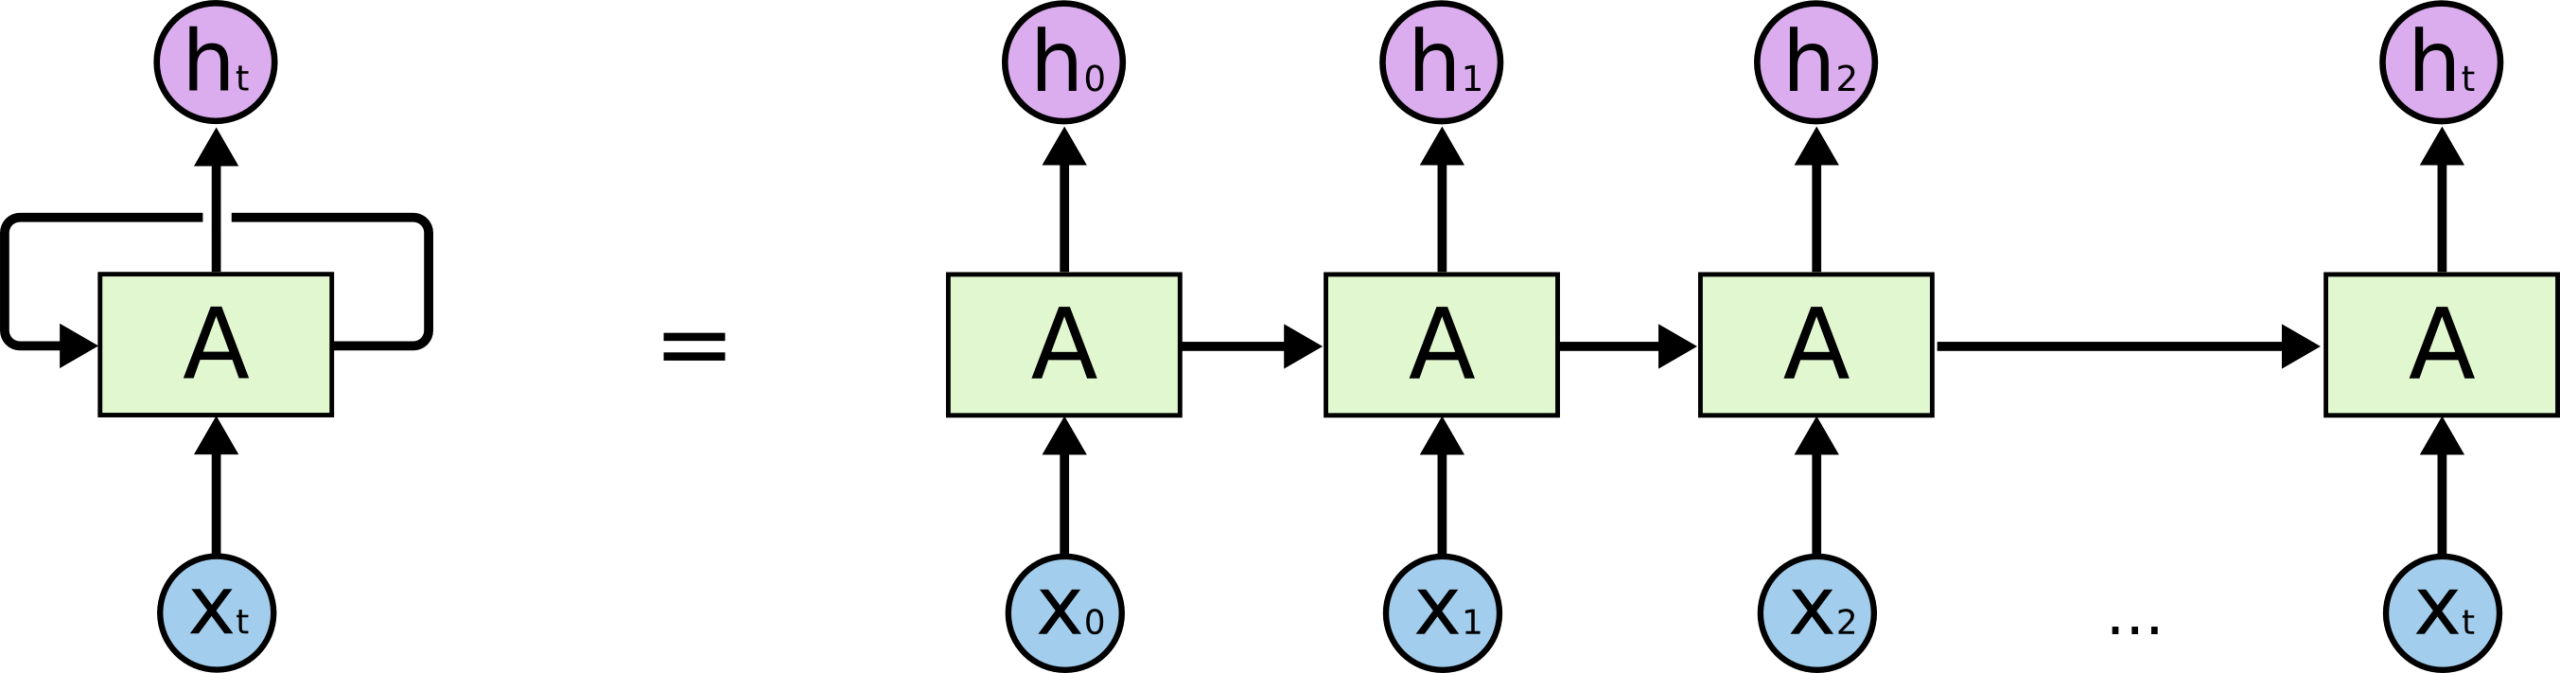

RNN 的核心在于循环连接（Recurrent Connection），即网络的输出不仅取决于当前输入，还取决于之前所有时间步的输入。这种结构使 RNN 能够处理任意长度的序列数据。  
 
RNN：通过循环连接将上一步的隐藏状态传递到下一步，形成"记忆"。  

每一步的输入 = 当前数据 + 上一步的隐藏状态。  

输出不仅依赖当前输入，还依赖之前所有步骤的上下文。     

In [ ]:
# 简单的 RNN 单元实现示例
import numpy as np

class SimpleRNN:
    def __init__(self, input_size, hidden_size):
        self.Wx = np.random.randn(hidden_size, input_size)  # 输入权重
        self.Wh = np.random.randn(hidden_size, hidden_size)  # 隐藏状态权重
        self.b = np.zeros((hidden_size, 1))  # 偏置项
    
    def forward(self, x, h_prev):
        h_next = np.tanh(np.dot(self.Wx, x) + np.dot(self.Wh, h_prev) + self.b)
        return h_next

RNN 的工作机制：  
RNN 在每个时间步 t 执行以下计算：  
- 接收当前输入 xₜ 和前一时刻的隐藏状态 hₜ₋₁  
- 计算新的隐藏状态 hₜ = f(Wₕₕ·hₜ₋₁ + Wₓₕ·xₜ + b)  
- 产生输出 yₜ = g(Wₕᵧ·hₜ + c)    

其中 f 和 g 通常是激活函数（如 tanh 或 softmax）。  

RNN 的优缺点  
优点：  
- 能够处理变长序列  
- 理论上可以记住任意长度的历史信息  
- 参数共享（同一组权重用于所有时间步）  

缺点：  
- 梯度消失/爆炸问题（难以学习长期依赖）  
- 计算效率较低（无法并行处理时间步）  

## 长短期记忆网络（LSTM）
LSTM（Long Short-Term Memory）是 RNN 的一种改进架构，专门设计来解决标准 RNN 的长期依赖问题  

LSTM 引入了三个门控机制和一个记忆单元：

|组件	|功能|
|---|---|
|输入门	|控制新信息的流入|
|遗忘门	|决定丢弃哪些旧信息|
|输出门	|控制输出的信息量|
|记忆单元|	保存长期状态|

LSTM 如何解决长期依赖问题
- 选择性记忆：遗忘门可以决定保留或丢弃特定信息
- 梯度通路：记忆单元提供了相对直接的梯度传播路径
- 信息保护：记忆内容不会被每个时间步的操作直接修改

```py
# LSTM 单元的基本实现
class LSTMCell:
    def __init__(self, input_size, hidden_size):
        # 组合所有门的权重
        self.W = np.random.randn(4*hidden_size, input_size+hidden_size)
        self.b = np.random.randn(4*hidden_size, 1)
    
    def forward(self, x, h_prev, c_prev):
        combined = np.vstack((h_prev, x))
        gates = np.dot(self.W, combined) + self.b
        
        # 分割得到各个门
        f_gate = sigmoid(gates[:hidden_size])  # 遗忘门
        i_gate = sigmoid(gates[hidden_size:2*hidden_size])  # 输入门
        o_gate = sigmoid(gates[2*hidden_size:3*hidden_size])  # 输出门
        c_candidate = np.tanh(gates[3*hidden_size:])  # 候选记忆
        
        # 更新记忆和隐藏状态
        c_next = f_gate * c_prev + i_gate * c_candidate
        h_next = o_gate * np.tanh(c_next)
        
        return h_next, c_next

## 门控循环单元（GRU）
GRU（Gated Recurrent Unit）是 LSTM 的简化版本，在保持相似性能的同时减少了参数数量  

|组件	|功能|
|---|---|
|更新门	|决定保留多少旧信息|
|重置门	|决定如何组合新旧信息|
|候选激活|	基于重置门计算的新状态|

```py
# GRU 单元的实现
class GRUCell:
    def __init__(self, input_size, hidden_size):
        self.W = np.random.randn(3*hidden_size, input_size+hidden_size)
        self.b = np.random.randn(3*hidden_size, 1)
    
    def forward(self, x, h_prev):
        combined = np.vstack((h_prev, x))
        gates = np.dot(self.W, combined) + self.b
        
        # 分割门控信号
        z = sigmoid(gates[:hidden_size])  # 更新门
        r = sigmoid(gates[hidden_size:2*hidden_size])  # 重置门
        h_candidate = np.tanh(np.dot(self.W[2*hidden_size:], 
                              np.vstack((r*h_prev, x))) + self.b[2*hidden_size:]
        
        # 更新隐藏状态
        h_next = (1-z)*h_prev + z*h_candidate
        return h_next

## 双向 RNN（Bi-RNN）
双向 RNN 通过同时考虑过去和未来的上下文信息，增强了序列建模能力。

Bi-RNN 包含两个独立的 RNN 层：

- 前向层：按时间顺序处理序列

- 反向层：按时间逆序处理序列

最终输出是这两个方向输出的组合（通常为拼接或求和）。

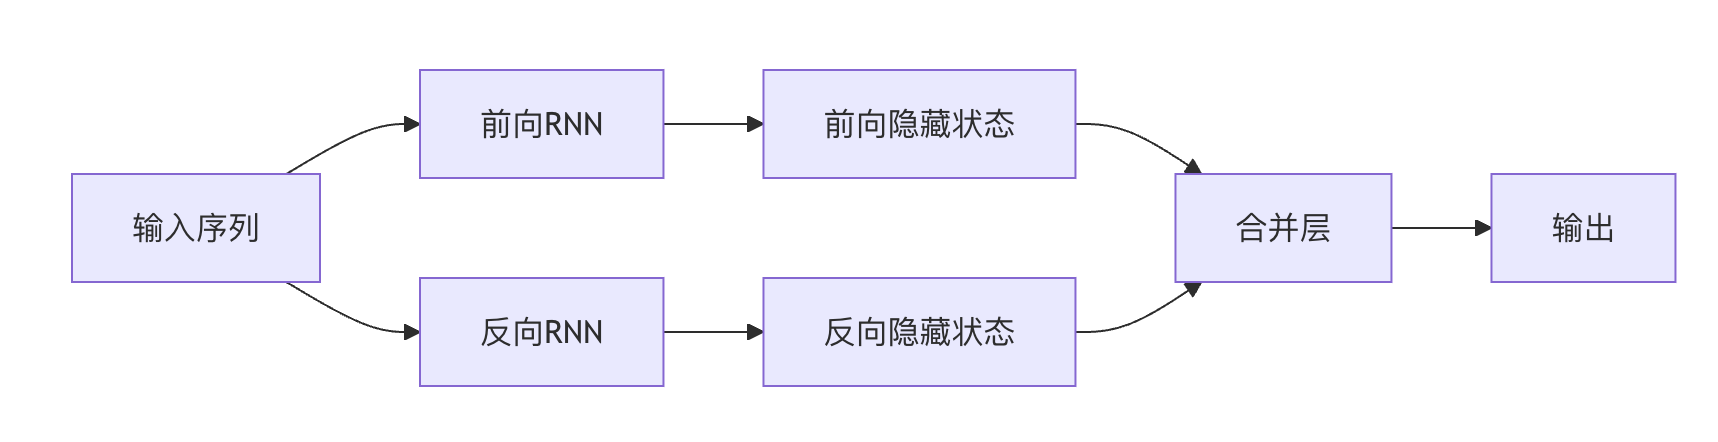

双向 RNN 的应用场景:
- 自然语言处理：词性标注、命名实体识别
- 语音识别：利用前后语境提高准确率
- 生物信息学：蛋白质结构预测
- 时间序列预测：考虑历史与未来趋势

双向 LSTM/GRU
现代应用中，双向 RNN 通常使用 LSTM 或 GRU 作为基础单元

```py
from tensorflow.keras.layers import Bidirectional, LSTM

model.add(Bidirectional(LSTM(64)))  # 创建双向LSTM层

# 注意力机制
注意力机制(Attention Mechanism)是深度学习中的一种重要技术，它模仿了人类视觉和认知过程中的注意力分配方式。  
就像你在阅读时会不自觉地将注意力集中在关键词上一样，注意力机制让神经网络能够动态地关注输入数据中最相关的部分。  

核心思想：  
根据输入的不同部分对当前任务的重要性，动态分配不同的权重。这种权重分配不是固定的，而是根据上下文动态计算的。  

数学表达：  
Attention(Q, K, V) = softmax(QK^T/√d_k)V

其中：  
Q (Query)：当前需要计算输出的查询项  
K (Key)：用于与查询项匹配的键  
V (Value)：与键对应的实际值  
d_k：键的维度，用于缩放点积结果  

为什么需要注意力机制？  
- 解决长距离依赖问题：传统RNN难以捕捉远距离词语间的关系  
- 并行计算能力：相比RNN的顺序处理，注意力可以并行计算  
- 可解释性：注意力权重可以直观展示模型关注的重点  

## 自注意力机制  
自注意力(Self-Attention)是注意力机制的一种特殊形式，它允许输入序列中的每个元素都与序列中的所有其他元素建立联系。

工作原理：  
- 对输入序列中的每个元素，计算其与所有元素的相似度得分  
- 使用softmax函数将这些得分转换为权重(0-1之间)  
- 用这些权重对对应的值进行加权求和，得到输出  
  
自注意力的优势
- 全局上下文感知：每个位置都能直接访问序列中所有位置的信息
- 位置无关性：不依赖序列顺序，适合处理各种结构化数据
- 高效计算：相比RNN的O(n)复杂度，自注意力可以并行计算

```py
# 简化的自注意力实现示例
import torch
import torch.nn.functional as F

def self_attention(query, key, value):
    scores = torch.matmul(query, key.transpose(-2, -1)) / (query.size(-1) ** 0.5)
    weights = F.softmax(scores, dim=-1)
    return torch.matmul(weights, value)

## 多头注意力
多头注意力(Multi-Head Attention)是自注意力的扩展，它将注意力机制并行执行多次，然后将结果拼接起来。  

结构组成
- 多个注意力头：通常使用8个或更多并行的注意力头
- 线性变换层：每个头有自己的Q、K、V变换矩阵
- 拼接和输出：将各头的输出拼接后通过线性层

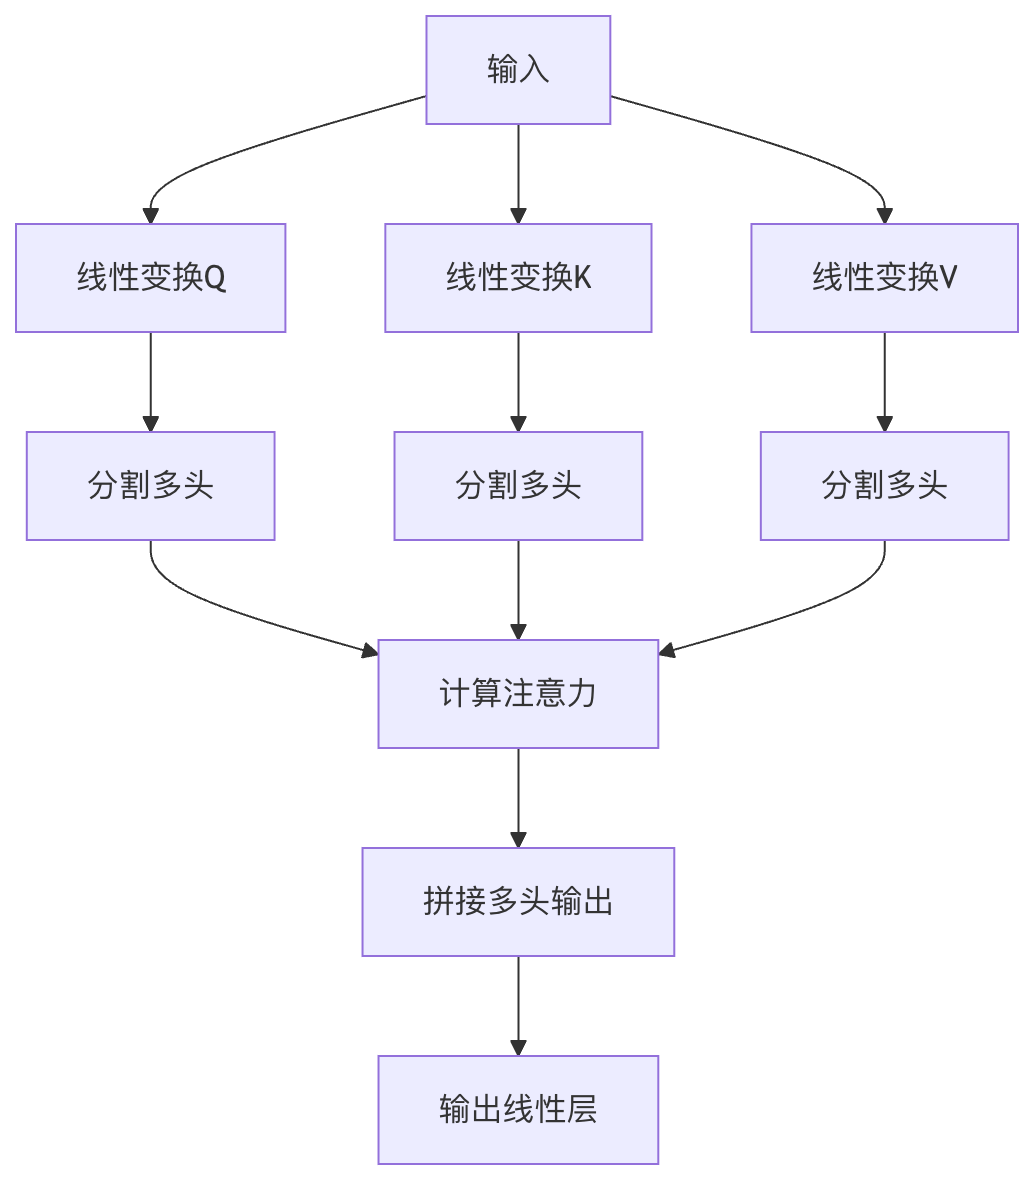

多头注意力的优势
- 捕捉不同关系：每个头可以学习关注不同方面的关系
- 增强表达能力：比单头注意力有更强的特征提取能力
- 稳定训练：多个头的组合可以减少模型对特定模式的依赖

```py
# 多头注意力实现示例
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
    
    def forward(self, query, key, value):
        batch_size = query.size(0)
        
        # 线性变换并分割多头
        Q = self.W_q(query).view(batch_size, -1, self.num_heads, self.d_k)
        K = self.W_k(key).view(batch_size, -1, self.num_heads, self.d_k)
        V = self.W_v(value).view(batch_size, -1, self.num_heads, self.d_k)
        
        # 计算注意力
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_k ** 0.5)
        weights = F.softmax(scores, dim=-1)
        output = torch.matmul(weights, V)
        
        # 拼接多头并输出
        output = output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        return self.W_o(output)

## 案例：BERT中的注意力
BERT(Bidirectional Encoder Representations from Transformers)是使用注意力机制的典型代表：  

- 双向自注意力：同时考虑左右上下文
- 12/24层Transformer：堆叠多头注意力层
- 预训练任务：通过掩码语言模型和下一句预测任务学习通用表示

```py
# 使用HuggingFace Transformers库调用BERT
from transformers import BertModel, BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

inputs = tokenizer("Hello, my dog is cute", return_tensors="pt")
outputs = model(**inputs)

# 获取注意力权重
attention = outputs.attentions  # 包含各层的注意力权重

## 练习1：实现基础注意力机制
```py
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleAttention(nn.Module):
    def __init__(self, hidden_size):
        super(SimpleAttention, self).__init__()
        self.attention = nn.Linear(hidden_size, 1)
    
    def forward(self, encoder_outputs):
        # encoder_outputs: [batch_size, seq_len, hidden_size]
        attention_scores = self.attention(encoder_outputs).squeeze(2)  # [batch_size, seq_len]
        attention_weights = F.softmax(attention_scores, dim=1)
        context_vector = torch.bmm(attention_weights.unsqueeze(1), encoder_outputs)  # [batch_size, 1, hidden_size]
        return context_vector.squeeze(1), attention_weights

## 练习2：可视化注意力权重
```py
import matplotlib.pyplot as plt
import seaborn as sns

def plot_attention(attention_weights, source_tokens, target_tokens):
    plt.figure(figsize=(10, 8))
    sns.heatmap(attention_weights, 
                xticklabels=source_tokens,
                yticklabels=target_tokens,
                cmap="YlGnBu")
    plt.xlabel("Source Tokens")
    plt.ylabel("Target Tokens")
    plt.title("Attention Weights Visualization")
    plt.show()

# 示例使用
source = ["The", "cat", "sat", "on", "the", "mat"]
target = ["Le", "chat", "s'est", "assis", "sur", "le", "tapis"]
attention = torch.rand(7, 6)  # 模拟的注意力权重
plot_attention(attention, source, target)

# Transformer架构
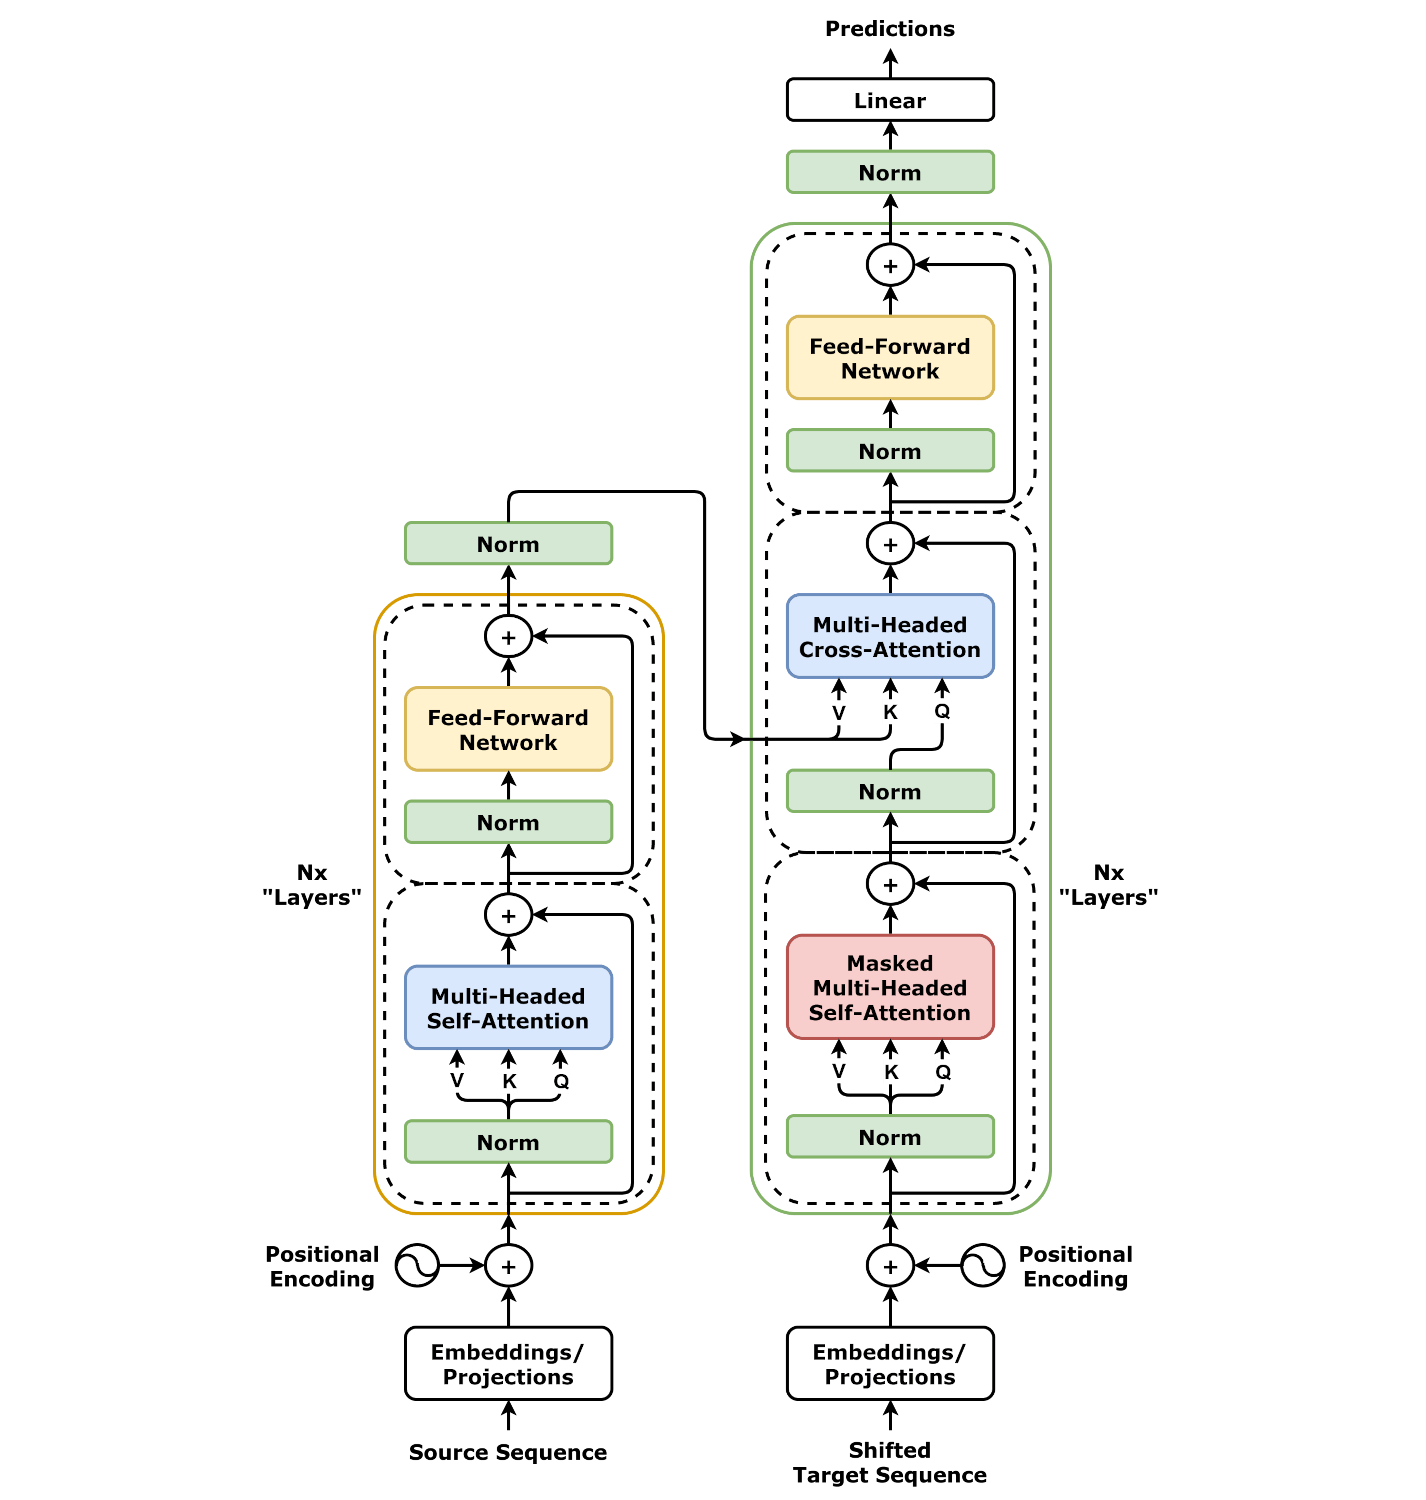
1. 输入处理（底部）  
- Embeddings/Projections（嵌入/投影层）  
作用：将输入的单词（或 token）转换成数字向量（比如 "猫" → [0.2, -0.5, 0.7…]）  

2. 编码器（左侧）
- Multi-Headed Self-Attention（多头自注意力）  
作用：让模型同时关注输入中的所有单词，并计算它们之间的关系。
举例：在句子"猫追老鼠"中，模型会学习"猫"和"老鼠"的关联比"猫"和"追"更强。
关键：并行处理所有单词，不像RNN需要逐个计算。

- Norm（层归一化）
作用：稳定训练过程，防止数值过大或过小。

- Feed-Forward Network（前馈神经网络）
作用：对每个单词的表示进行进一步加工（比如提取更复杂的特征）。
类比：像对"猫"的向量做一次深度解读，补充细节（比如"猫是哺乳动物"）。

3. 解码器（右侧）
- Masked Multi-Headed Self-Attention（掩码多头自注意力）
作用：训练时防止模型"作弊"（只能看到当前和之前的单词，不能看未来的）。
举例：生成"我爱__"时，模型只能基于"我""爱"预测下一个词，不能提前知道答案是"你"。

- Multi-Headed Cross-Attention（多头交叉注意力）
作用：让解码器询问编码器："关于输入，我应该重点关注什么？"
场景：翻译任务中，解码器生成英文时，会参考编码器处理的中文输入。

- Norm 和 Feed-Forward Network
与编码器类似，对解码器的表示进行归一化和深度处理。

4. 输出（顶部）
- Linear（线性层）
作用：将解码器的输出映射到词表（比如预测下一个词是"你"的概率最高）。
举例：输入"我爱"，模型输出"你"的概率可能是80%，"吃饭"的概率是10%…

## 核心思想
**自注意力机制(Self-Attention)**  
Transformer 的核心思想是完全依赖注意力机制（无需循环或卷积结构）来捕捉输入序列中的全局依赖关系，从而实现高效的并行计算和更强的长距离依赖建模。

# Python NLP 生态
- NLTK - 学术研究首选的自然语言处理工具包
- spaCy - 工业级高效 NLP 框架
- jieba - 最流行的中文分词工具
- HanLP - 功能全面的中文 NLP 处理库

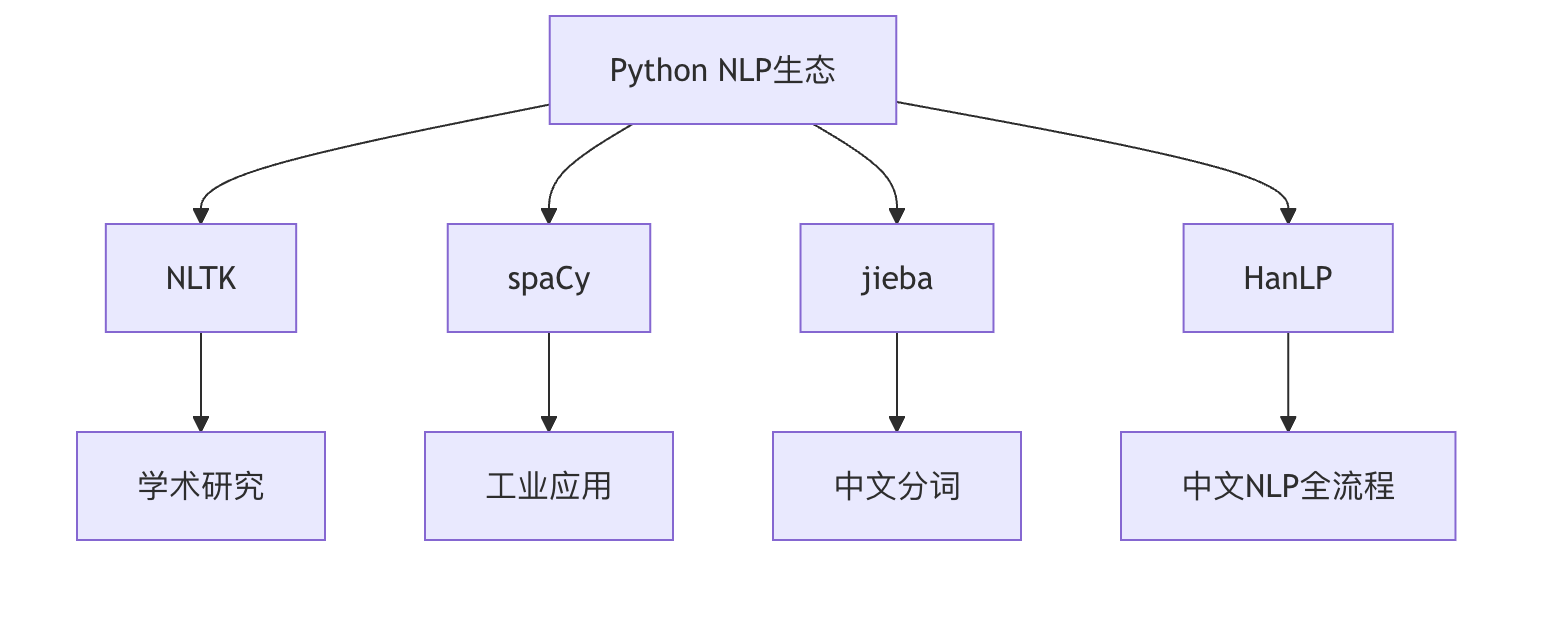

## NLTK
NLTK（Natural Language Toolkit）是最著名的 Python NLP 库之一，由宾夕法尼亚大学开发，特别适合教学和研究用途。

核心功能
- 文本分词（Tokenization）
- 词性标注（POS Tagging）
- 命名实体识别（NER）
- 情感分析（Sentiment Analysis）
- 词干提取（Stemming）和词形还原（Lemmatization）

|优点	|缺点|
|---|---|
|功能全面，覆盖 NLP 主要任务|	执行效率较低|
|文档完善，学习资源丰富|	需要额外下载数据包|
|适合教学和研究|	对中文支持有限|

```py
import nltk
nltk.download('punkt')  # 下载必要的数据包

# 示例：文本分词
from nltk.tokenize import word_tokenize
text = "Natural language processing is fascinating."
tokens = word_tokenize(text)
print(tokens)  # 输出: ['Natural', 'language', 'processing', 'is', 'fascinating', '.']

## spaCy
spaCy 是一个专注于工业应用的现代 NLP 库，以其高效性和易用性著称。

核心特点
- 预训练模型支持
- 管道式处理机制
- 高性能的神经网络实现
- 多语言支持（包括中文）

```py
# 安装英文模型: python -m spacy download en_core_web_sm
# 安装中文模型: python -m spacy download zh_core_web_sm

import spacy

# 加载英文模型
nlp = spacy.load("en_core_web_sm")
doc = nlp("Apple is looking at buying U.K. startup for $1 billion")

# 提取命名实体
for ent in doc.ents:
    print(ent.text, ent.label_)
# 输出: Apple ORG
#       U.K. GPE
#       $1 billion MONEY

## jieba
jieba 是专门针对中文设计的分词工具，以其简单易用和高效准确著称。

三种分词模式
- 精确模式：最准确的分词结果
- 全模式：扫描所有可能成词的词语
- 搜索引擎模式：对长词再切分

```py
import jieba

# 精确模式分词
seg_list = jieba.cut("我爱自然语言处理", cut_all=False)
print("精确模式: " + "/".join(seg_list)) 
# 输出: 精确模式: 我/爱/自然语言/处理

# 添加自定义词典
jieba.load_userdict("userdict.txt")  # 自定义词典文件

## HanLP
HanLP 是由一系列模型与算法组成的 NLP 工具包，目标是普及自然语言处理在生产环境中的应用。

功能特性
- 支持多种分词模式
- 命名实体识别
- 依存句法分析
- 文本分类
- 情感分析

```py
from hanlp import HanLP

# 分词示例
print(HanLP.segment('你好，欢迎使用HanLP！'))
# 输出: [你好/vl, ，/w, 欢迎/v, 使用/v, HanLP/nx, ！/w]

# 依存句法分析
sentence = HanLP.parseDependency("我爱自然语言处理")
print(sentence)

## 案例：中文文本分析流程
```py
# 结合多个工具的中文文本处理流程
import jieba
from hanlp import HanLP
import spacy

text = "自然语言处理是人工智能的重要分支，近年来发展迅速。"

# 1. 使用jieba分词
words = list(jieba.cut(text))
print("分词结果:", words)

# 2. 使用HanLP进行词性标注
print("\n词性标注:")
print(HanLP.segment(text))

# 3. 使用spaCy的英文模型处理英文部分
nlp = spacy.load("en_core_web_sm")
doc = nlp("Natural Language Processing is amazing.")
print("\n英文实体识别:")
for ent in doc.ents:
    print(ent.text, ent.label_)